# Limit cycles of Triangulation strategy 

## import

In [2]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd
import os
import sys
sys.path.append("../General_Functions/")
import config as cfg

from Geometric_functions import * # Import rotation from euler angles
#from Evolution_Traj import * # Import time integration for trjectories
#from Time_Int_Traj import * # Import evolution function
#from BasicData import *  # Nagents, R0, V
#from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution import Evolution_Triangulation # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 

#from common_functions.Flow_functions import GradientStresslet, GradientStokeslet
from common_functions.Strategies_Evolution import Evolution_Triangulation
#from common_functions.Geometric_functions import Rotation

## Parameters

In [3]:
Grad = GradientStokeslet
GradName = ' GradientStokeslet '
Strategy = Evolution_Triangulation
twist = 0.2
dt = 0.05  # Time steps for time integration
e = np.array([0, 0, 1])  # Orientation of symmetry axis of source flow
AntennaeLength = 0.001  # Distance between sensors
Duration = 6000
traj_i = 1  # 1 or 3
camera_eye = dict(x=.6, y=.8, z=.4)
R0 = 100

thetas = np.pi * np.array([0.1, 0.2, 0.3,  0.4, 0.5])
phis = np.pi * np.array([0.3, 0.5, 0.7,  1.4, 1.5])
theta, phi = thetas[traj_i], phis[traj_i]
AgentPosition = R0*np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)]).T.reshape((3))
AgentPosition = np.array([1, 0, 4])
RotationMatrix = Rotation(-.3, -0.5, -0.2)
n = np.dot(RotationMatrix, [1, 0, 0])
b = np.dot(RotationMatrix, [0, 1, 0])
t = np.dot(RotationMatrix, [0, 0, 1])

print("Agent position:", AgentPosition)
print("Initial vector t", t)
print("Initial vector n", n)


Agent position: [1 0 4]
Initial vector t [0.14167993 0.45801271 0.87758256]
Initial vector n [ 0.88476979 -0.45619119  0.09524715]


## Useful plot functions (sphere, cylinder)

In [4]:
def create_sphere(radius=1, center=(0, 0, 0), resolution=64):
    """Generate sphere coordinates."""
    u = np.linspace(0, 2 * np.pi, resolution)  # Longitude
    v = np.linspace(0, np.pi, resolution)      # Latitude
    u, v = np.meshgrid(u, v)

    x = center[0] + radius * np.cos(u) * np.sin(v)
    y = center[1] + radius * np.sin(u) * np.sin(v)
    z = center[2] + radius * np.cos(v)

    return x, y, z

In [5]:
# Function to draw a cylinder with axis along n0, basis n1,n2
def create_cylinder(n2, n1, n0, ymax, zmax, resolution=128):
    # Generate cylindrical coordinates
    theta = np.linspace(0, 2 * np.pi, resolution)
    z = np.linspace(-1.25, 1.25, 2)
    theta, z = np.meshgrid(theta, z)
    
    x = ymax * np.cos(theta)
    y = zmax * np.sin(theta)
    X = x * n0[0] + y * n1[0] + z * n2[0]
    Y = x * n0[1] + y * n1[1] + z * n2[1]
    Z = x * n0[2] + y * n1[2] + z * n2[2]
    
    return X, Y, Z

## Numerical integration
In the space of orientation of the swimming direction

In [6]:
# Numerical realization
t0, t1, t2 = np.zeros(Duration), np.zeros(Duration), np.zeros(Duration)
n0, n1, n2 = np.zeros(Duration), np.zeros(Duration), np.zeros(Duration)

for time in range(Duration):
    n, b, t, _ = Strategy(n, b, t, AntennaeLength, AgentPosition, Grad, e, dt, 0., twist)
    
    t0[time], t1[time], t2[time] = t
    n0[time], n1[time], n2[time] = n

In [7]:
print(t2)

[ 0.87193849  0.86544344  0.85801046 ... -0.6844304  -0.68568907
 -0.68696534]


In [8]:
# Create a folder to store files
output_folder = "trajectories_fig3A"
os.makedirs(output_folder, exist_ok=True)

# Save t's trajectory
data = {"X": t0, "Y": t1, "Z": t2}
df = pd.DataFrame(data)

filename = os.path.join(output_folder, f"vector_t_numeric{traj_i}.csv")
df.to_csv(filename, index=False)
print(f"Saved: {filename}")

# Save n's trajectory
data = {"X": n0, "Y": n1, "Z": n2}
df = pd.DataFrame(data)

filename = os.path.join(output_folder, f"vector_n_numeric{traj_i}.csv")
df.to_csv(filename, index=False)
print(f"Saved: {filename}")

Saved: trajectories_fig3A\vector_t_numeric1.csv
Saved: trajectories_fig3A\vector_n_numeric1.csv


## Figure: trajectory of t and n

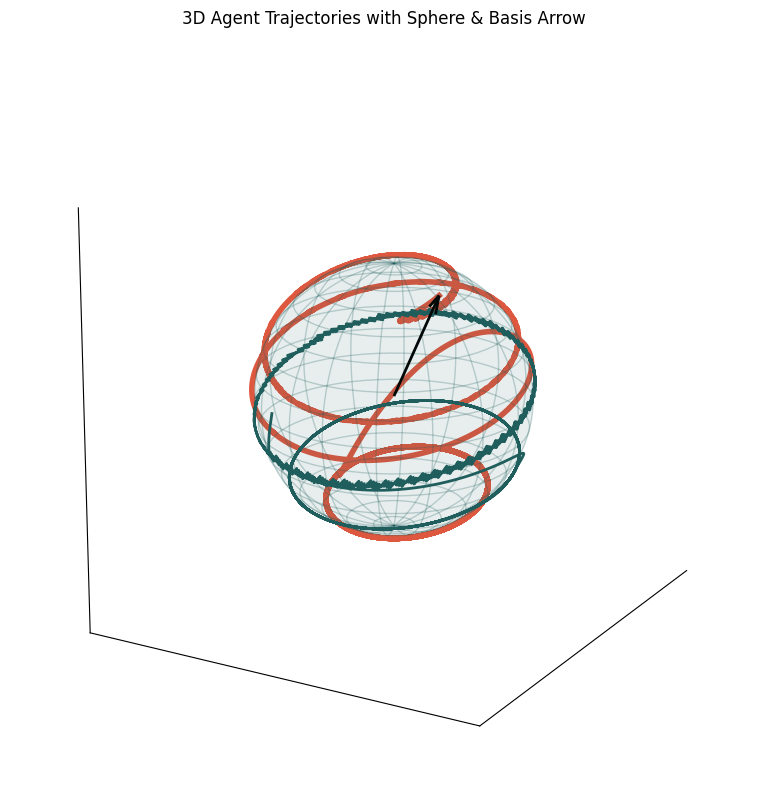

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# -----------------------
# Trajectories
# -----------------------
ax.plot(t0, t1, t2,
        color=cfg.PREDATOR_COLOR,
        linewidth=4)

ax.plot(n0, n1, n2,
        color=cfg.PREY_COLOR,
        linewidth=2)

# -----------------------
# Arrow from origin to first t-point
# -----------------------
i = 0
tx, ty, tz = t0[i], t1[i], t2[i]

ax.quiver(0, 0, 0,
          tx, ty, tz,
          color='black',
          linewidth=2,
          arrow_length_ratio=0.15)

# -----------------------
# Sphere
# -----------------------
Xsphere, Ysphere, Zsphere = create_sphere(radius=0.98)

# Surface
ax.plot_surface(
    Xsphere, Ysphere, Zsphere,
    color=cfg.PREY_COLOR,
    alpha=0.05,
    linewidth=0,
    shade=False
)

# Latitude lines
for x, y, z in zip(Xsphere[::4], Ysphere[::4], Zsphere[::4]):
    ax.plot(x, y, z,
            color=cfg.PREY_COLOR,
            linewidth=1,
            alpha=0.25)

# Longitude lines
Xs, Ys, Zs = Xsphere.T, Ysphere.T, Zsphere.T
for x, y, z in zip(Xs[::4], Ys[::4], Zs[::4]):
    ax.plot(x, y, z,
            color=cfg.PREY_COLOR,
            linewidth=1,
            alpha=0.25)

# -----------------------
# Axes styling
# -----------------------
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_zlim([-1.5, 1.5])

ax.set_box_aspect([1, 1, 1])  # equal aspect ratio

# Remove grid, ticks, panes
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)

ax.set_title("3D Agent Trajectories with Sphere & Basis Arrow")

# -----------------------
# Camera view (approximate Plotly camera_eye)
# -----------------------
ax.view_init(elev=20, azim=30)

# -----------------------
# Save figure
# -----------------------
plt.tight_layout()
plt.savefig(fr"Fig3B_{GradName}_x_{AgentPosition[0]}_y_{AgentPosition[1]}_z_{AgentPosition[2]}.png", dpi=300)
plt.show()


# Plot

In [10]:
# Show the interactive plot
fig.show()

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_101804\659560333.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


# Fixed points representation
Plot cylunder drawn from eigenvector of strain matrix

## Calculation of limit cycles

In [11]:
G = Grad(e, AgentPosition/R0)
symG = 0.5 * (G + G.T)
antisymG = 0.5 * (G - G.T)

vaps, veps = np.linalg.eigh(symG)

# 4. Sort eigenvalues by absolute value (descending)
idx_sorted = np.argsort(np.abs(vaps))[::-1]
vaps = vaps[idx_sorted]
veps = veps[:, idx_sorted]

# Define e1 as the eigenvector with the largest |eigenvalue|
e1 = veps[:, 0]

# Define e3 as a normalized vector orthogonal to AgentPosition
AgentPos_norm = AgentPosition / np.linalg.norm(AgentPosition)

# Loop over eigenvectors to find one orthogonal to AgentPosition
for i in range(3):
    vi = veps[:, i]
    if np.abs(np.dot(vi, AgentPos_norm)) < 1e-6:  # numerically orthogonal
        e3 = vi
        break
else:
    raise ValueError("No eigenvector orthogonal to AgentPosition found.")

# Make sure e1 and e3 are orthogonal; if not, re-orthonormalize
e3 /= np.linalg.norm(e3)
e1 = e1 - np.dot(e1, e3) * e3
e1 = e1 / np.linalg.norm(e1)
e1 *= np.sign(np.dot(e1, - AgentPosition))

# Define e2 = e3 × e1 to complete right-handed orthonormal basis
e2 = np.cross(e1, e3)
e2 /= np.linalg.norm(e2)

# Assemble the rotation matrix B = [e1 | e2 | e3]
B = np.stack([e1, e2, e3], axis=-1)  # shape (3, 3)

# 10. Change basis: express G in new basis
G_new = (B.T @ G @ B) / vaps[0] # shape (3,3)

s = G_new[1,1]
Omega = G_new[0,1]
print("s,Omega", s, Omega)

t_2max = np.sqrt(s / (s-1))
t_3max = np.sqrt((s**2 + s) / (s**2 + 2*s + Omega**2))

n_2max = np.sqrt(1 / (1-s))
n_3max = np.sqrt(1 / (2+s))

angles = np.linspace(0, 2*np.pi, 512).reshape(1, 512)

limitcyclet = (
    e3[:,np.newaxis] * t_3max * np.cos(angles) + 
    e2[:,np.newaxis] * t_2max * np.sin(angles) + 
    e1[:,np.newaxis] * np.sqrt(1 - (t_3max * np.cos(angles))**2 - (t_2max * np.sin(angles))**2)
)

limitcyclen = (
    e3[:,np.newaxis] * n_3max * np.cos(angles) + 
    e2[:,np.newaxis] * n_2max * np.sin(angles) - 
    e1[:,np.newaxis] * np.sqrt(1 - (n_3max * np.cos(angles))**2 - (n_2max * np.sin(angles))**2)
)

print("e1:", e1)
print("e2:", e2)
print("e3:", e3)

print("\nElliptical Cylinder's for t:\n axis", e1)
print("major length e3", t_3max)
print("minor length e2", t_2max)

print("\n Elliptical Cylinder's for n:\n axis", e1)
print("major length e3", n_3max)
print("minor length e2", n_2max)


s,Omega -0.5000000000000001 0.12500000000000008
e1: [-0.24253563  0.         -0.9701425 ]
e2: [-0.9701425   0.          0.24253563]
e3: [ 0. -1.  0.]

Elliptical Cylinder's for t:
 axis [-0.24253563  0.         -0.9701425 ]
major length e3 0.5834599659915781
minor length e2 0.5773502691896258

 Elliptical Cylinder's for n:
 axis [-0.24253563  0.         -0.9701425 ]
major length e3 0.816496580927726
minor length e2 0.816496580927726


In [12]:
# Create a folder to store files
output_folder = "trajectories_fig3A"
os.makedirs(output_folder, exist_ok=True)

# Save t's trajectory
data = {"X": limitcyclet[0], "Y": limitcyclet[1], "Z": limitcyclet[2]}
df = pd.DataFrame(data)

filename = os.path.join(output_folder, f"vector_t_limitcycle{traj_i}.csv")
df.to_csv(filename, index=False)
print(f"Saved: {filename}")

# Save n's trajectory
data = {"X": limitcyclen[0], "Y": limitcyclen[1], "Z": limitcyclen[2]}
df = pd.DataFrame(data)

filename = os.path.join(output_folder, f"vector_n_limitcycle{traj_i}.csv")
df.to_csv(filename, index=False)
print(f"Saved: {filename}")

Saved: trajectories_fig3A\vector_t_limitcycle1.csv
Saved: trajectories_fig3A\vector_n_limitcycle1.csv


## Figure of limit cycles

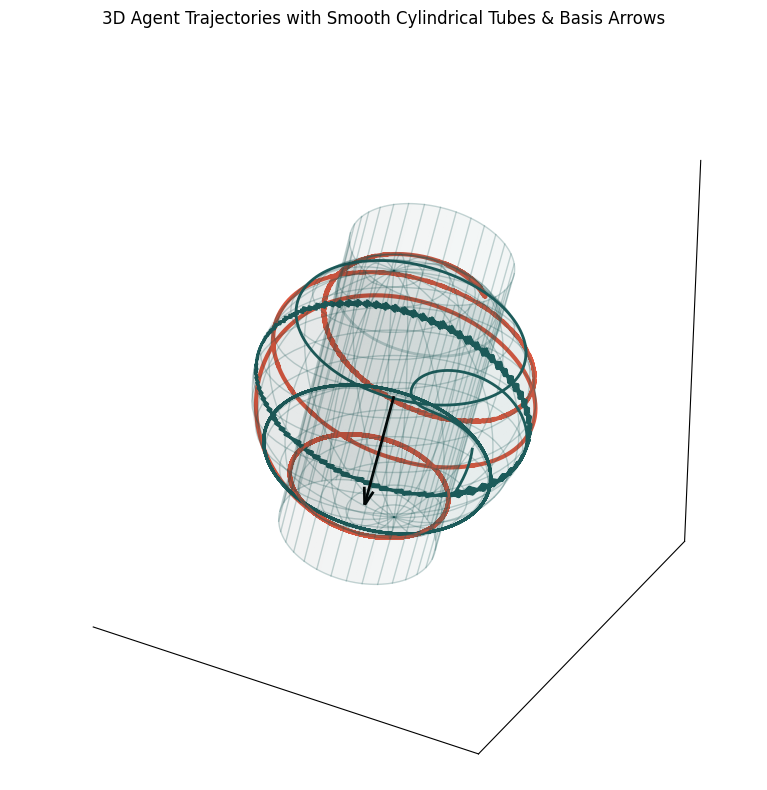

In [13]:

# Create figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- Trajectories ---
ax.plot(t0, t1, t2, color=cfg.PREDATOR_COLOR, linewidth=3)
ax.plot(n0, n1, n2, color=cfg.PREY_COLOR, linewidth=2)

# Limit cycles
ax.plot(limitcyclet[0], limitcyclet[1], limitcyclet[2],
        color=cfg.PREDATOR_COLOR, linewidth=2)

ax.plot(limitcyclen[0], limitcyclen[1], limitcyclen[2],
        color=cfg.PREY_COLOR, linewidth=2)

# --- Sphere ---
Xsphere, Ysphere, Zsphere = create_sphere(radius=1)

ax.plot_surface(
    Xsphere, Ysphere, Zsphere,
    color=cfg.PREY_COLOR,
    alpha=0.05,
    linewidth=0
)

# Wireframe sphere
for x, y, z in zip(Xsphere[::4], Ysphere[::4], Zsphere[::4]):
    ax.plot(x, y, z, color=cfg.PREY_COLOR, alpha=0.25, linewidth=1)

Xs, Ys, Zs = Xsphere.T, Ysphere.T, Zsphere.T
for x, y, z in zip(Xs[::4], Ys[::4], Zs[::4]):
    ax.plot(x, y, z, color=cfg.PREY_COLOR, alpha=0.25, linewidth=1)

# --- Cylinder ---
Xcyl, Ycyl, Zcyl = create_cylinder(e1, e3, e2, t_2max, t_3max, resolution=128)

ax.plot_surface(
    Xcyl, Ycyl, Zcyl,
    color=cfg.PREY_COLOR,
    alpha=0.05,
    linewidth=0
)

# Wireframe cylinder
for x, y, z in zip(Xcyl, Ycyl, Zcyl):
    ax.plot(x, y, z, color=cfg.PREY_COLOR, alpha=0.25, linewidth=1)

Xc, Yc, Zc = Xcyl.T, Ycyl.T, Zcyl.T
for x, y, z in zip(Xc[::4], Yc[::4], Zc[::4]):
    ax.plot(x, y, z, color=cfg.PREY_COLOR, alpha=0.25, linewidth=1)

# --- Intersections ---
ax.plot(-limitcyclet[0], -limitcyclet[1], -limitcyclet[2],
        color=cfg.PREY_COLOR, linewidth=2, alpha=0.25)

ax.plot(-limitcyclen[0], -limitcyclen[1], -limitcyclen[2],
        color=cfg.PREY_COLOR, linewidth=2, alpha=0.25)

# --- Eigenvector arrow ---
tx, ty, tz = e1
ax.quiver(
    0, 0, 0,
    tx, ty, tz,
    color='black',
    linewidth=2,
    arrow_length_ratio=0.15,
    length=1.0,
    normalize=True
)

# --- Axes settings ---
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_zlim([-1.5, 1.5])

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Agent Trajectories with Smooth Cylindrical Tubes & Basis Arrows")

# Remove panes and grid
ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_visible(False)

# Save figure
plt.tight_layout()
plt.savefig("Fig3C.png", dpi=300)
plt.show()

# Plot